# Experiment No 8

## Aim:
To implement K-Means and Hierarchical Clustering algorithms on the Glass Identification dataset to identify patterns among different types of glass based on chemical composition.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
glass = fetch_ucirepo(id=42)
df = pd.concat([glass.data.features, glass.data.targets], axis=1)

display(df.head())
print(df.shape)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


(214, 10)


## Preprocessing

In [3]:
# Use only feature columns (unsupervised learning → no target)
X = df.drop(columns=['Type_of_glass'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Variance explained by 2 PCs: 50.68%


## K-Means – Optimal K via Elbow Method & Silhouette Score

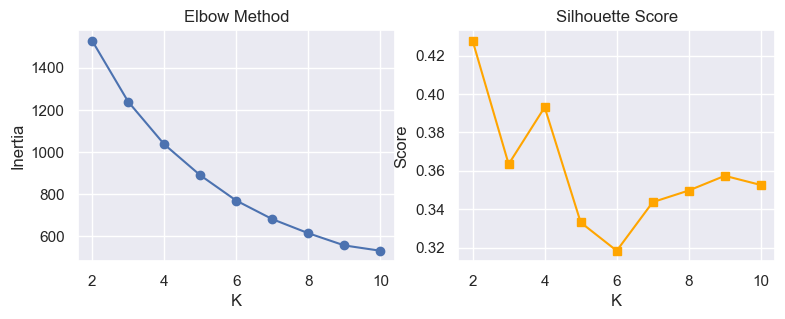

In [4]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='s', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.show()

## K-Means – Fit & Visualise

,K,Inertia,Silhouette Score
0,3,1239.4157,0.3635


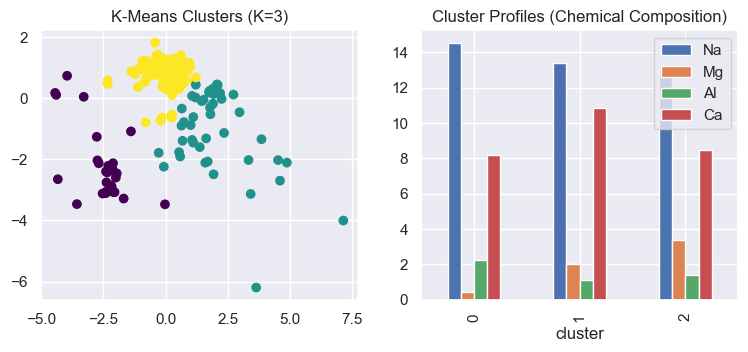

In [5]:
best_k = 3

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

display(pd.DataFrame({
    'K': [best_k],
    'Inertia': [km.inertia_],
    'Silhouette Score': [silhouette_score(X_scaled, km_labels)]
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis')
axes[0].set_title(f'K-Means Clusters (K={best_k})')

# Cluster profile
df_plot = pd.DataFrame(X, columns=df.columns[:-1])
df_plot['cluster'] = km_labels

cluster_means = df_plot.groupby('cluster')[['Na','Mg','Al','Ca']].mean()
cluster_means.plot(kind='bar', ax=axes[1])

axes[1].set_title('Cluster Profiles (Chemical Composition)')

plt.show()

## Hierarchical Clustering – Dendrogram

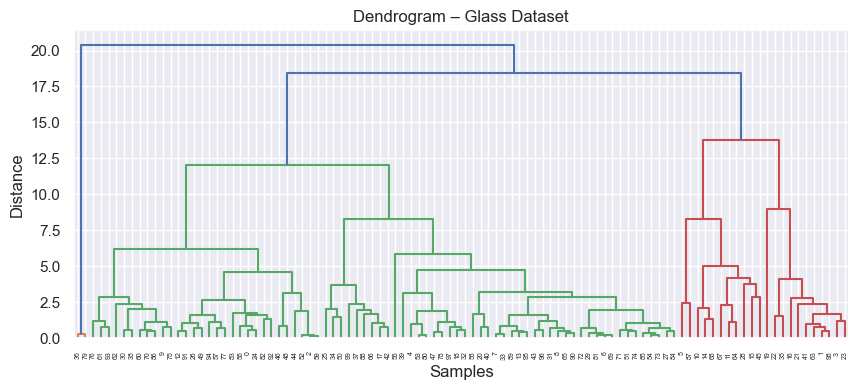

In [6]:
sample_idx = np.random.RandomState(42).choice(len(X_scaled), 100, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(10,4))
dendrogram(Z)
plt.title('Dendrogram – Glass Dataset')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

## Hierarchical Clustering – Fit & Visualise

,K,Silhouette Score
0,3,0.4522


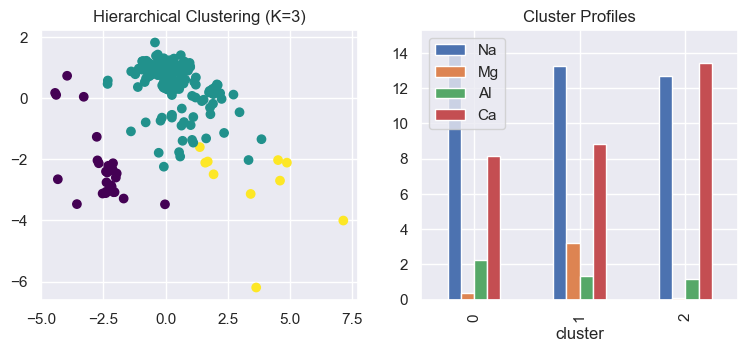

In [7]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

display(pd.DataFrame({
    'K': [best_k],
    'Silhouette Score': [silhouette_score(X_scaled, agg_labels)]
}).round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sc2 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis')
axes[0].set_title(f'Hierarchical Clustering (K={best_k})')

df_plot2 = pd.DataFrame(X, columns=df.columns[:-1])
df_plot2['cluster'] = agg_labels

cluster_means2 = df_plot2.groupby('cluster')[['Na','Mg','Al','Ca']].mean()
cluster_means2.plot(kind='bar', ax=axes[1])

axes[1].set_title('Cluster Profiles')

plt.show()

## Conclusion

Both K-Means and Hierarchical Clustering successfully group glass samples based on their chemical composition. The clusters reveal patterns in elements like Sodium, Magnesium, Aluminum, and Calcium, showing how different glass types can be grouped based on similar properties. This demonstrates the usefulness of unsupervised learning for material classification.